# Lecture 1 Exercises: Worked Solutions

## Linear Regression, Model Complexity, and Regularisation

This notebook is a worked-solutions version of `ex.ipynb`. It keeps the same structure, but the derivations, code, and reflection prompts have been completed.

The main ideas are still the same:

- deriving linear regression from a probabilistic model
- understanding underfitting and overfitting through polynomial models
- controlling model complexity with ridge regularisation


In [27]:
import numpy as np
import matplotlib.pyplot as plt

style_name = "seaborn-v0_8-whitegrid"
plt.style.use(style_name if style_name in plt.style.available else "default")
np.set_printoptions(precision=3, suppress=True)


def mse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return np.mean((y_true - y_pred) ** 2)


def add_bias_column(x):
    x = np.asarray(x).reshape(-1, 1)
    return np.hstack([np.ones((x.shape[0], 1)), x])


def polynomial_design_matrix(x, degree):
    x = np.asarray(x).reshape(-1)
    return np.column_stack([x ** k for k in range(degree + 1)])


def make_linear_data(n=40, noise_std=0.35, seed=7):
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(-2.0, 2.0, size=n))
    y_true = 1.5 - 2.0 * x
    y = y_true + rng.normal(0.0, noise_std, size=n)
    return x, y, y_true


def make_curved_data(n=45, noise_std=0.18, seed=11):
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(-1.0, 1.0, size=n))
    y_true = np.sin(np.pi * x) + 0.3 * x ** 2
    y = y_true + rng.normal(0.0, noise_std, size=n)
    return x, y, y_true


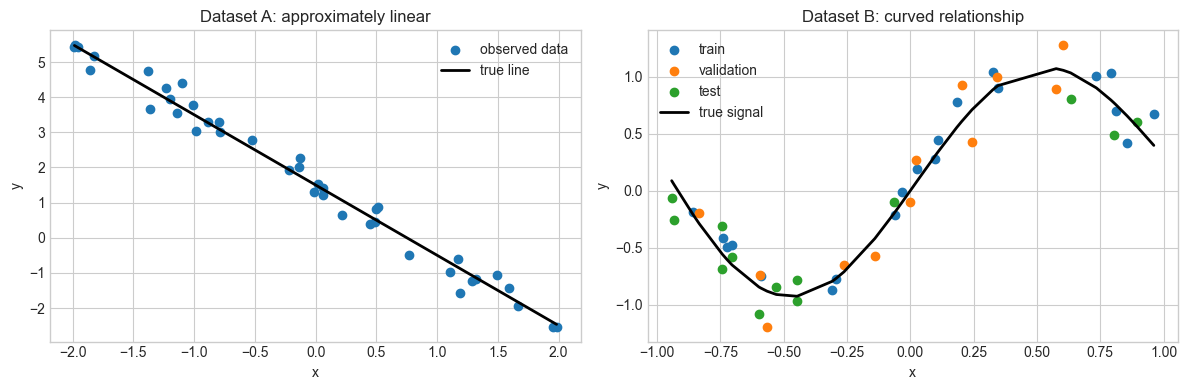

In [28]:
x_lin, y_lin, y_lin_true = make_linear_data()
x_curve, y_curve, y_curve_true = make_curved_data()

rng = np.random.default_rng(5)
indices = rng.permutation(len(x_curve))
train_idx = indices[:20]
valid_idx = indices[20:32]
test_idx = indices[32:]

x_train, y_train = x_curve[train_idx], y_curve[train_idx]
x_valid, y_valid = x_curve[valid_idx], y_curve[valid_idx]
x_test, y_test = x_curve[test_idx], y_curve[test_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x_lin, y_lin, color="tab:blue", label="observed data")
axes[0].plot(x_lin, y_lin_true, color="black", linewidth=2, label="true line")
axes[0].set_title("Dataset A: approximately linear")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].scatter(x_train, y_train, color="tab:blue", label="train")
axes[1].scatter(x_valid, y_valid, color="tab:orange", label="validation")
axes[1].scatter(x_test, y_test, color="tab:green", label="test")
axes[1].plot(x_curve, y_curve_true, color="black", linewidth=2, label="true signal")
axes[1].set_title("Dataset B: curved relationship")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()

plt.tight_layout()
plt.show()


## Exercise 1: Linear Regression as Maximum Likelihood

Assume the data follow the model

$$y_i = \theta_0 + \theta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2).$$

When you switch to matrix notation, let $y = (y_1, \ldots, y_n)^T$ be the column vector of targets, and let $X$ be the design matrix whose $i$-th row is $(1, x_i)$.

Work through the following derivation.

1. Write down the likelihood $p(y_i \mid x_i, \theta_0, \theta_1, \sigma^2)$ for a single observation.
2. Write the likelihood for the full dataset assuming independent observations.
3. Take the logarithm and simplify the log-likelihood up to additive constants.
4. Show that maximising the log-likelihood is equivalent to minimising the residual sum of squares

$$\sum_{i=1}^n (y_i - \theta_0 - \theta_1 x_i)^2.$$

5. Rewrite the model in matrix form $y = X\theta + \varepsilon$ and derive the normal equation

$$X^T X \hat{\theta} = X^T y.$$

6. Under what condition is the closed-form estimator unique?


### Solution derivation

1. For one observation, the Gaussian noise model gives

$$p(y_i \mid x_i, \theta_0, \theta_1, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - \theta_0 - \theta_1 x_i)^2}{2\sigma^2}\right).$$

2. Assuming the observations are independent, the full likelihood is

$$p(y \mid X, \theta_0, \theta_1, \sigma^2) = \prod_{i=1}^n p(y_i \mid x_i, \theta_0, \theta_1, \sigma^2)$$

so

$$p(y \mid X, \theta_0, \theta_1, \sigma^2) = (2\pi\sigma^2)^{-n/2} \exp\left(-\frac{1}{2\sigma^2} \sum_{i=1}^n (y_i - \theta_0 - \theta_1 x_i)^2\right).$$

3. Taking logs gives

$$\log L(\theta_0, \theta_1, \sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (y_i - \theta_0 - \theta_1 x_i)^2.$$

For fixed $\sigma^2$, the first term is constant with respect to $(\theta_0, \theta_1)$.

4. Maximising this log-likelihood is therefore equivalent to minimising

$$\sum_{i=1}^n (y_i - \theta_0 - \theta_1 x_i)^2,$$

because the log-likelihood differs from minus the residual sum of squares only by an additive constant and the positive scale factor $1/(2\sigma^2)$.

5. In matrix form,

$$y = X\theta + \varepsilon, \qquad y = (y_1, \ldots, y_n)^T, \qquad \theta = (\theta_0, \theta_1)^T.$$

Here $X$ is the design matrix whose $i$-th row is $(1, x_i)$.

The least-squares objective is

$$L(\theta) = \|y - X\theta\|_2^2 = (y - X\theta)^T (y - X\theta).$$

Differentiating with respect to $\theta$ gives

$$\nabla_\theta L(\theta) = -2X^T(y - X\theta).$$

Setting the gradient to zero yields

$$X^T(y - X\hat{\theta}) = 0 \quad \Longrightarrow \quad X^T X\hat{\theta} = X^T y.$$

This is the normal equation.

6. The closed-form estimator is unique when $X^T X$ is invertible, equivalently when the columns of $X$ are linearly independent. For simple linear regression, that means the input values cannot all be identical.


## Exercise 2: Ordinary Least Squares in Code

Use the closed-form solution you derived above to fit the linear dataset.

Tasks:

- complete `fit_ols` using the normal equation
- complete `predict`
- run the analysis cell and compare your fitted parameters with the true line
- check whether the estimate is close to the generating parameters $(1.5, -2.0)$
- inspect the design matrix example below and explain how the polynomial basis changes the feature space


In [29]:
example_x = np.array([-1.0, 0.0, 2.0])
print("Linear design matrix:")
print(add_bias_column(example_x))
print("")
print("Polynomial design matrix of degree 3:")
print(polynomial_design_matrix(example_x, degree=3))


Linear design matrix:
[[ 1. -1.]
 [ 1.  0.]
 [ 1.  2.]]

Polynomial design matrix of degree 3:
[[ 1. -1.  1. -1.]
 [ 1.  0.  0.  0.]
 [ 1.  2.  4.  8.]]


### Solution note

`add_bias_column(x)` maps each scalar input to `[1, x]`, which is the feature space for an ordinary straight-line model. `polynomial_design_matrix(x, degree=3)` instead maps each input to `[1, x, x^2, x^3]`, so the regression model is still linear in the parameters but can represent a nonlinear curve in the original input variable.


In [30]:
def fit_ols(X, y):
    """Return the ordinary least squares estimate."""
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)

    xtx = X.T @ X
    xty = X.T @ y
    print(xtx.shape, xty.shape)
    theta_hat = np.linalg.solve(xtx, xty)
    return theta_hat


def predict(X, theta):
    X = np.asarray(X)
    theta = np.asarray(theta).reshape(-1)
    return X @ theta


(2, 2) (2,)
Estimated parameters: [ 1.498 -2.023]
Training MSE: 0.0921
Expected: the fitted parameters should be close to [1.5, -2.0].


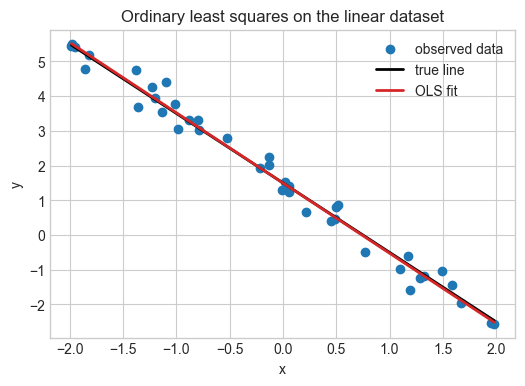

In [31]:
X_lin = add_bias_column(x_lin)
theta_lin = fit_ols(X_lin, y_lin)
y_lin_hat = predict(X_lin, theta_lin)

print("Estimated parameters:", theta_lin)
print(f"Training MSE: {mse(y_lin, y_lin_hat):.4f}")
print("Expected: the fitted parameters should be close to [1.5, -2.0].")

plt.figure(figsize=(6, 4))
plt.scatter(x_lin, y_lin, color="tab:blue", label="observed data")
plt.plot(x_lin, y_lin_true, color="black", linewidth=2, label="true line")
plt.plot(x_lin, y_lin_hat, color="tab:red", linewidth=2, label="OLS fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ordinary least squares on the linear dataset")
plt.legend()
plt.show()


### Interpretation

The fitted parameters are approximately `[1.498, -2.023]`, which is very close to the generating line `[1.5, -2.0]`. The small difference is exactly what we expect from finite data with Gaussian noise.


## Exercise 3: Underfitting and Overfitting with Polynomial Features

We now move to the curved dataset. Fit polynomial regression models with degrees 1, 3, 9, and 15.

Tasks:

1. Fit each model using only the training split.
2. Compute both training MSE and validation MSE.
3. Plot the fitted curve for each degree on a dense grid of input points.
4. Decide which model underfits and which model overfits.
5. Explain why the model with the lowest training error may still be a poor choice.


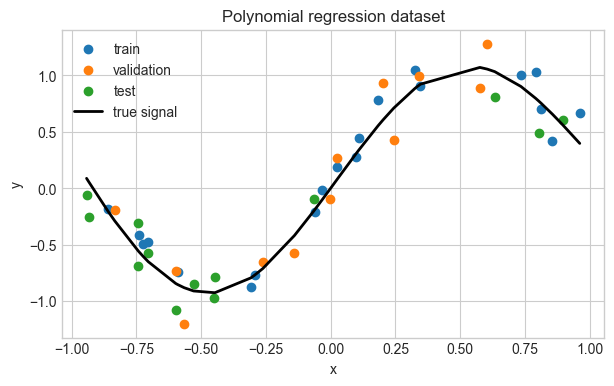

In [32]:
plt.figure(figsize=(7, 4))
plt.scatter(x_train, y_train, color="tab:blue", label="train")
plt.scatter(x_valid, y_valid, color="tab:orange", label="validation")
plt.scatter(x_test, y_test, color="tab:green", label="test")
plt.plot(x_curve, y_curve_true, color="black", linewidth=2, label="true signal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial regression dataset")
plt.legend()
plt.show()


In [42]:
def fit_polynomial_model(x, y, degree):
    """Fit a polynomial model of the requested degree using OLS."""
    X = polynomial_design_matrix(x, degree)
    print("X", X.shape)
    return fit_ols(X, y)


degrees = [1, 3, 9, 15]
results = []

for degree in degrees:
    theta = fit_polynomial_model(x_train, y_train, degree)
    print("theta", theta.shape)
    print(x_train.shape)
    X_train_degree = polynomial_design_matrix(x_train, degree)
    X_valid_degree = polynomial_design_matrix(x_valid, degree)
    y_train_hat = predict(X_train_degree, theta)
    y_valid_hat = predict(X_valid_degree, theta)

    results.append(
        {
            'degree': degree,
            'theta': theta,
            'train_mse': mse(y_train, y_train_hat),
            'valid_mse': mse(y_valid, y_valid_hat),
        }
    )

assert results, "Fill in the loop above before continuing."
results


X (20, 2)
(2, 2) (2,)
theta (2,)
(20,)
X (20, 4)
(4, 4) (4,)
theta (4,)
(20,)
X (20, 10)
(10, 10) (10,)
theta (10,)
(20,)
X (20, 16)
(16, 16) (16,)
theta (16,)
(20,)


[{'degree': 1,
  'theta': array([0.122, 0.908]),
  'train_mse': np.float64(0.1355892088899562),
  'valid_mse': np.float64(0.231410966798667)},
 {'degree': 3,
  'theta': array([ 0.06 ,  2.755,  0.397, -3.101]),
  'train_mse': np.float64(0.025045660804812703),
  'valid_mse': np.float64(0.0469024027564375)},
 {'degree': 9,
  'theta': array([  0.05 ,   4.094,  -0.3  , -17.503,   4.085,  54.519,  -4.654,
         -85.932,  -0.134,  47.373]),
  'train_mse': np.float64(0.005314064598361889),
  'valid_mse': np.float64(0.04596628115691139)},
 {'degree': 15,
  'theta': array([     0.072,      3.437,     -8.354,     10.755,    393.966,
            -75.019,  -4836.632,   -998.113,  22120.22 ,   4658.474,
         -47407.775,  -5057.837,  48677.096,  -1599.711, -19389.559,
           3479.415]),
  'train_mse': np.float64(0.0009672484272233679),
  'valid_mse': np.float64(3.9024654826565723)}]

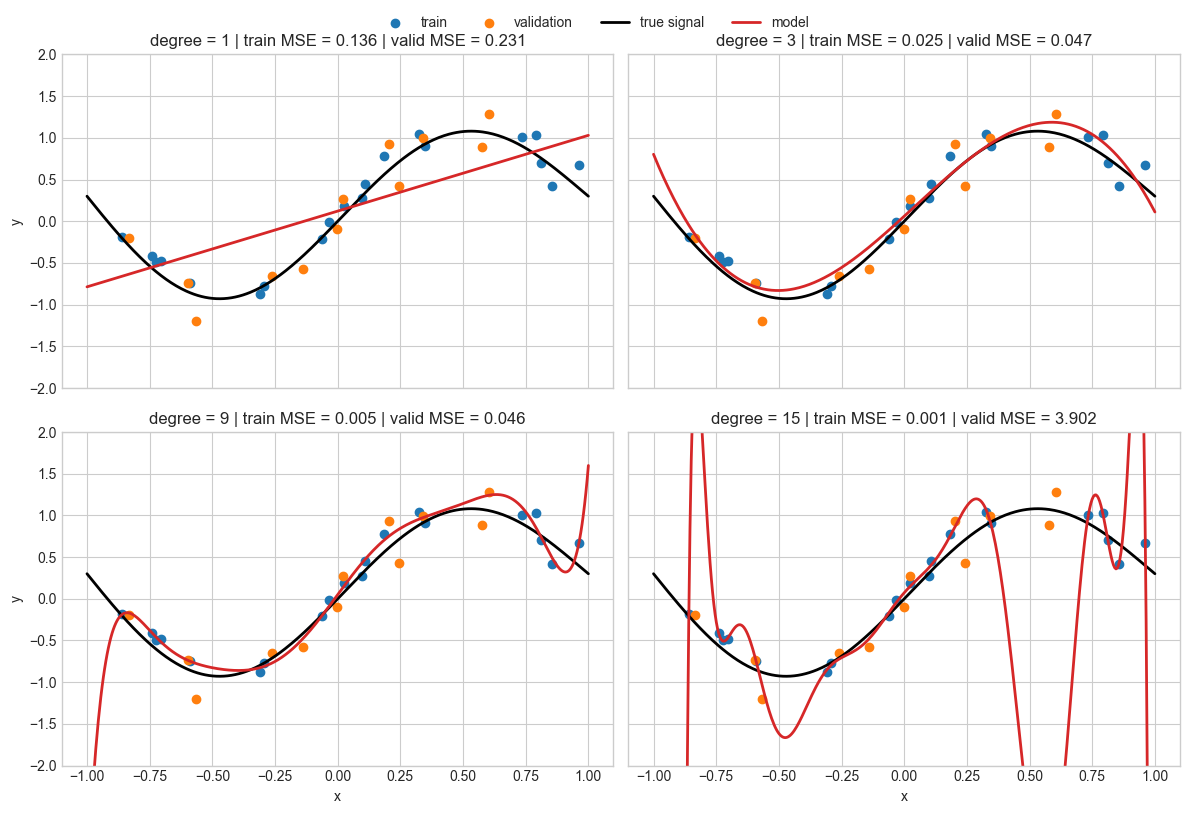

degree =  1 | train MSE = 0.1356 | validation MSE = 0.2314
degree =  3 | train MSE = 0.0250 | validation MSE = 0.0469
degree =  9 | train MSE = 0.0053 | validation MSE = 0.0460
degree = 15 | train MSE = 0.0010 | validation MSE = 3.9025


In [34]:
grid = np.linspace(-1.0, 1.0, 400)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, result in zip(axes.flat, results):
    degree = result['degree']
    theta = result['theta']
    y_grid = polynomial_design_matrix(grid, degree) @ theta

    ax.scatter(x_train, y_train, color="tab:blue", label="train")
    ax.scatter(x_valid, y_valid, color="tab:orange", label="validation")
    ax.plot(grid, np.sin(np.pi * grid) + 0.3 * grid ** 2, color="black", linewidth=2, label="true signal")
    ax.plot(grid, y_grid, color="tab:red", linewidth=2, label="model")
    ax.set_title(
        f"degree = {degree} | train MSE = {result['train_mse']:.3f} | valid MSE = {result['valid_mse']:.3f}"
    )

for ax in axes[-1, :]:
    ax.set_xlabel("x")

for ax in axes[:, 0]:
    ax.set_ylabel("y")

for ax in axes.ravel():
    ax.set_ylim(-2., 2.)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

for result in results:
    print(
        f"degree = {result['degree']:>2} | train MSE = {result['train_mse']:.4f} | validation MSE = {result['valid_mse']:.4f}"
    )


### Reflection answers

- The smallest training error comes from degree `15` (`train MSE \approx 0.0010`), because it is flexible enough to almost interpolate the training data.
- The best validation error among the unregularised models comes from degree `9` on this split (`valid MSE \approx 0.0460`), with degree `3` extremely close behind (`\approx 0.0469`). In practice, degree `3` would still be a very reasonable simpler choice.
- Degree `1` is clearly underfitting: it cannot capture the curved signal, so both training and validation errors stay relatively high.
- Degree `15` is clearly overfitting: the training error becomes tiny, but the validation error explodes (`\approx 3.90`) because the curve bends sharply to chase noise in the training set.
- As the degree increases, the fitted curve becomes more flexible. That helps at first, but eventually the curve becomes wiggly and unstable near gaps in the data.
- If we increased the number of training points, the higher-degree models would usually become more stable because there would be more information constraining the coefficients. That tends to reduce variance and make overfitting less severe.


## Exercise 4: Ridge Regularisation

High-degree polynomial models can have very large coefficients and unstable predictions. Ridge regression controls this by adding a penalty to the objective:

$$J(\theta) = \|y - X\theta\|_2^2 + \lambda \|\theta\|_2^2.$$

Tasks:

1. Derive the ridge normal equation and show that

$$(X^T X + \lambda I)\,\hat{\theta}_{\mathrm{ridge}} = X^T y.$$

2. Explain why practitioners often choose not to penalise the intercept term.
3. Predict how increasing $\lambda$ should affect coefficient size, bias, and variance.
4. Use the degree-15 model and compare several values of $\lambda$.


### Solution derivation

1. Start from the ridge objective

$$J(\theta) = \|y - X\theta\|_2^2 + \lambda \|\theta\|_2^2.$$

Using matrix notation,

$$J(\theta) = (y - X\theta)^T(y - X\theta) + \lambda \theta^T\theta.$$

Differentiate with respect to $\theta$:

$$\nabla_\theta J(\theta) = -2X^T(y - X\theta) + 2\lambda \theta.$$

Set the gradient to zero:

$$-2X^T y + 2X^T X\,\hat{\theta}_{\mathrm{ridge}} + 2\lambda\,\hat{\theta}_{\mathrm{ridge}} = 0.$$

Rearranging gives the ridge normal equation

$$(X^T X + \lambda I)\,\hat{\theta}_{\mathrm{ridge}} = X^T y.$$

If we do not penalise the intercept, we replace $I$ with a diagonal matrix $\Lambda = \operatorname{diag}(0, 1, \ldots, 1)$, so the fitted system becomes

$$(X^T X + \lambda \Lambda)\,\hat{\theta}_{\mathrm{ridge}} = X^T y.$$

2. Practitioners often leave the intercept unpenalised because it only shifts the baseline level of the predictions. Penalising it can bias the whole fit up or down even when the main problem is the size of the slope or higher-order coefficients.

3. As $\lambda$ increases, the coefficients are pushed toward zero, so coefficient norms shrink, variance decreases, and the model becomes smoother. The tradeoff is that bias increases because the model is less free to match the data closely.

4. That pattern is exactly what we see in this notebook. With `\lambda = 0`, the degree-15 model has tiny training error but enormous coefficient norm and terrible validation error. A very small penalty such as `10^{-4}` shrinks the coefficients dramatically and brings the validation error back down to about `0.047`. If `\lambda` becomes too large, both training and validation errors increase because the model becomes too rigid.


In [35]:
def fit_ridge(X, y, lam):
    """Fit ridge regression without penalising the intercept term."""
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)

    penalty = np.eye(X.shape[1])
    penalty[0, 0] = 0.0
    theta_hat = np.linalg.solve(X.T @ X + lam * penalty, X.T @ y)
    return theta_hat


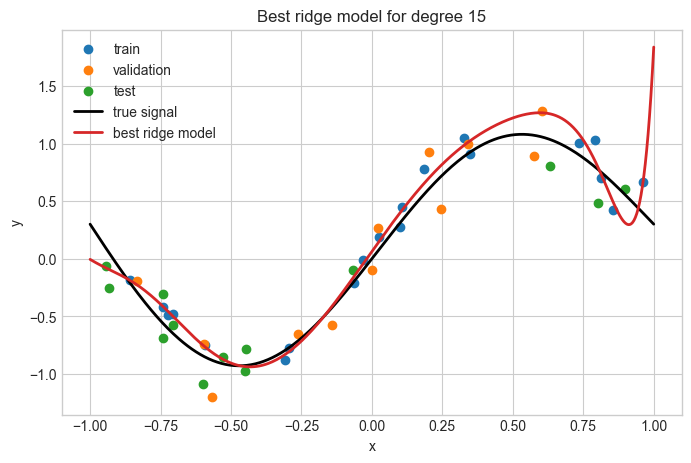

lambda =     0.0 | train MSE = 0.0010 | validation MSE = 3.9025 | ||w|| = 74623.8210
lambda =  0.0001 | train MSE = 0.0054 | validation MSE = 0.0470 | ||w|| = 12.8095
lambda =   0.001 | train MSE = 0.0070 | validation MSE = 0.0505 | ||w|| = 6.1416
lambda =    0.01 | train MSE = 0.0097 | validation MSE = 0.0502 | ||w|| = 4.7057
lambda =     0.1 | train MSE = 0.0387 | validation MSE = 0.0767 | ||w|| = 2.5465
lambda =     1.0 | train MSE = 0.1167 | validation MSE = 0.2229 | ||w|| = 0.9622
lambda =    10.0 | train MSE = 0.2285 | validation MSE = 0.4183 | ||w|| = 0.3420

Selected lambda: 0.0001
Validation MSE of selected model: 0.0470
Test MSE of selected model: 0.0493


In [36]:
degree = 15
X_train = polynomial_design_matrix(x_train, degree)
X_valid = polynomial_design_matrix(x_valid, degree)
X_test = polynomial_design_matrix(x_test, degree)
grid = np.linspace(-1.0, 1.0, 400)
X_grid = polynomial_design_matrix(grid, degree)

lambdas = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
ridge_results = []

for lam in lambdas:
    theta = fit_ridge(X_train, y_train, lam)
    y_train_hat = X_train @ theta
    y_valid_hat = X_valid @ theta

    ridge_results.append(
        {
            'lambda': lam,
            'theta': theta,
            'train_mse': mse(y_train, y_train_hat),
            'valid_mse': mse(y_valid, y_valid_hat),
            'coefficient_norm': np.linalg.norm(theta[1:]),
        }
    )

assert ridge_results, "Fill in the lambda sweep above before continuing."

best_entry = min(ridge_results, key=lambda item: item['valid_mse'])
best_theta = best_entry['theta']
test_mse = mse(y_test, X_test @ best_theta)

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color="tab:blue", label="train")
plt.scatter(x_valid, y_valid, color="tab:orange", label="validation")
plt.scatter(x_test, y_test, color="tab:green", label="test")
plt.plot(grid, np.sin(np.pi * grid) + 0.3 * grid ** 2, color="black", linewidth=2, label="true signal")
plt.plot(grid, X_grid @ best_theta, color="tab:red", linewidth=2, label="best ridge model")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Best ridge model for degree {degree}")
plt.legend()
plt.show()

for entry in ridge_results:
    print(
        f"lambda = {entry['lambda']:>7} | train MSE = {entry['train_mse']:.4f} | validation MSE = {entry['valid_mse']:.4f} | ||w|| = {entry['coefficient_norm']:.4f}"
    )

print()
print(f"Selected lambda: {best_entry['lambda']}")
print(f"Validation MSE of selected model: {best_entry['valid_mse']:.4f}")
print(f"Test MSE of selected model: {test_mse:.4f}")


## Optional extension

- Compare the best ridge model with the best unregularised polynomial model on the test set.
- Repeat the experiment with more training points. Does the degree-15 model still overfit as badly?
- Replace the closed-form fit with `np.linalg.lstsq` and compare the numerical behaviour.
- Standardise the polynomial features before fitting ridge regression. Does the preferred value of $\lambda$ change?


## Take-away questions

1. Why does a Gaussian noise model naturally lead to squared-error loss?
2. Why can a model with extremely low training error still generalise poorly?
3. How does ridge regularisation change the effective complexity of a linear model?
4. In your own words, how are linear regression, overfitting, and regularisation connected?


### Take-away answers

1. A Gaussian noise model makes the negative log-likelihood proportional to the sum of squared residuals, so minimising squared error is the same optimisation problem as maximising the likelihood.
2. Extremely low training error can still generalise poorly when a flexible model fits noise or accidental quirks of the training sample instead of the underlying signal.
3. Ridge regularisation shrinks coefficients toward zero, which lowers effective complexity, reduces variance, and usually produces smoother predictions.
4. Linear regression gives the basic fitting framework, polynomial features make that framework more flexible, overfitting appears when flexibility outruns the data, and regularisation counteracts that by discouraging unnecessarily large coefficients.


## Exercise 5: Fisher Information Across Regression Models

Fisher information measures how sharply peaked the likelihood is around the parameter value supported by the data. In this context, large curvature means the data constrain that direction of $\theta$ strongly, while very small eigenvalues indicate weakly constrained directions and potentially unstable estimates.

For a Gaussian linear model with known noise variance, you should find that

$$I(\theta) = \frac{1}{\sigma^2} X^T X.$$

This applies both to straight-line regression and to polynomial regression, because both models are linear in the parameter vector $\theta$.

In this exercise, compare:

- the degree-1, degree-3, degree-9, and degree-15 polynomial models on the curved dataset
- the degree-15 model with and without ridge regularisation

Tasks:

1. Starting from the Gaussian log-likelihood for the linear regression MLE, derive the Fisher information matrix for $\theta$ and show that it reduces to the expression above.
2. Compute the Fisher information matrix for each unregularised model on the training split, using the known synthetic noise level $\sigma = 0.18$.
3. For each matrix, inspect its trace, eigenvalues, and condition number.
4. For ridge regression, compare the ordinary Fisher information with the regularised precision matrix

$$I_{\mathrm{eff}}(\theta) = I(\theta) + \frac{\lambda}{\sigma^2} \Lambda,$$

where $\Lambda$ is diagonal, with a zero for the intercept term and ones for the remaining coefficients.

5. Explain why a high-degree model can have a larger trace but still be badly conditioned.
6. Explain why ridge improves numerical stability even though it does not add new information from the data likelihood.


### Solution derivation

For the Gaussian linear model, the Fisher information tells us how sharply curved the log-likelihood is around the parameter values preferred by the data. In practice, that means directions with larger Fisher information are estimated more precisely, while directions with tiny Fisher-information eigenvalues are poorly constrained and numerically fragile.

Starting from the Gaussian log-likelihood used to obtain the linear regression MLE,

$$\log p(y \mid X, \theta) = c - \frac{1}{2\sigma^2}(y - X\theta)^T(y - X\theta).$$

Differentiating twice with respect to $\theta$ gives

$$\nabla^2_{\theta} \log p(y \mid X, \theta) = -\frac{1}{\sigma^2} X^T X.$$

Therefore the Fisher information is

$$I(\theta) = -\mathbb{E}\left[\nabla^2_{\theta} \log p(y \mid X, \theta)\right] = \frac{1}{\sigma^2} X^T X.$$

The key point is that this depends on the design matrix and the noise variance, not on whether we later solve the optimisation problem with or without ridge regularisation.

Ridge does not change the Fisher information coming from the likelihood. Instead, it adds quadratic curvature through the penalty. If we interpret ridge as a Gaussian prior or as a regularised objective, the effective precision becomes

$$I_{\mathrm{eff}}(\theta) = I(\theta) + \frac{\lambda}{\sigma^2} \Lambda,$$

where $\Lambda$ leaves the intercept unpenalised. This is why ridge can stabilise estimation even though it does not create new information in the observed data.
